# Chapter 4 — Sample Weights

AFML by Marcos López de Prado

Real Bitcoin Trade Data · March 2026

This notebook demonstrates the sample weighting techniques from AFML Chapter 4, applied to real triple-barrier-labeled events:

- **Section 4.5** — Average uniqueness and sequential bootstrap
- **Section 4.6** — Sample weights by absolute return attribution
- **Section 4.7** — Time decay factors


## Setup

In [ ]:
import sys
import os

# Add ch02, ch03, ch04, and project root to path.
#
# NOTE: We hardcode the AFML root path here instead of deriving it from
# os.getcwd(). Jupyter's working directory depends on where the KERNEL was
# launched from (e.g. VS Code may start it in your Downloads folder), not
# where this .ipynb file is saved — so os.getcwd()-based path math is
# unreliable across machines/launch methods. If you move this project to a
# different location, update AFML_ROOT below to match.
AFML_ROOT = r'C:\ws\AFML'

root = AFML_ROOT
ch02 = os.path.join(root, 'ch02')
ch03 = os.path.join(root, 'ch03')
ch04 = os.path.join(root, 'ch04')
sys.path.insert(0, root)
sys.path.insert(0, ch02)
sys.path.insert(0, ch03)
sys.path.insert(0, ch04)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import bars      # from ch02
import labeling  # from ch03

from sample_weights.co_events             import mp_num_co_events
from sample_weights.uniqueness            import get_average_uniqueness
from sample_weights.indicator_matrix      import get_ind_matrix
from sample_weights.avg_uniqueness_matrix import get_avg_uniqueness
from sample_weights.sequential_bootstrap  import seq_bootstrap
from sample_weights.monte_carlo           import get_rnd_t1, aux_mc, main_mc
import time
from sample_weights.return_attribution    import get_sample_weights
from sample_weights.time_decay            import get_time_decay
from sample_weights.real_data_bootstrap_comparison import compare_bootstrap_on_real_events

sns.set_style("whitegrid")
%matplotlib inline

## Load Real Bitcoin Tick Data and Build Triple Barrier Events

Same pipeline as Chapter 3: raw ticks → dollar bars → CUSUM filter → triple barrier labeling.
We reuse these real, path-dependent events as the foundation for everything in this chapter.

In [ ]:
data_path = os.path.join(root, 'input_data', 'BTCTUSD-trades-2026-03.csv')

print("Loading tick data...")
raw = pd.read_csv(data_path, header=None,
                  names=['TradeID', 'Price', 'Volume', 'QuoteVolume',
                         'Timestamp', 'IsBuyerMaker', 'IsBestMatch'])

raw['Date']  = pd.to_datetime(raw['Timestamp'], unit='us')
raw['Label'] = raw['IsBuyerMaker'].apply(lambda x: -1 if x else 1)

df = raw[['Date', 'Price', 'Volume', 'Label']].copy()
df['Dollar'] = df['Price'] * df['Volume']
df = bars.delta(df)

print(f"Loaded {len(df):,} ticks")

Loading tick data...
Loaded 9,205 ticks


In [ ]:
print("Generating dollar bars...")
dollar_bars = bars.dollar_bars(df, thresh=10000)
dollar_bars = dollar_bars.set_index('Date')
close = dollar_bars['Close']
print(f"Dollar bars: {len(close)} bars")

print("\nApplying CUSUM filter...")
cusum_df = pd.DataFrame({'Date': close.index, 'Price': close.values})
events_dates = bars.cusum_filter(cusum_df, h=500)
print(f"CUSUM events: {len(events_dates)}")

Generating dollar bars...
Dollar bars: 249 bars

Applying CUSUM filter...
CUSUM events: 104


In [ ]:
print("Computing daily volatility and triple barrier events...")
daily_vol = labeling.get_daily_vol(close, span0=100)
t1_series = labeling.add_vertical_barrier(close, events_dates, num_days=3)
tb_events = labeling.get_events(
    close=close, t_events=events_dates, pt_sl=[1, 1],
    trgt=daily_vol, min_ret=0.005, t1=t1_series
)
tb_events = tb_events.dropna(subset=['t1'])
print(f"Triple barrier events with valid t1: {len(tb_events)}")
tb_events.head()

Computing daily volatility and triple barrier events...
Triple barrier events with valid t1: 88


,t1,trgt
2026-03-02 13:05:06.160435,2026-03-02 13:50:21.805687,0.005431
2026-03-02 15:30:49.837102,2026-03-02 16:46:56.199924,0.007640
2026-03-02 16:46:56.199924,2026-03-02 19:00:58.984721,0.013461
2026-03-02 19:00:58.984721,2026-03-03 09:28:01.084240,0.015808
2026-03-03 03:09:58.655387,2026-03-03 09:28:01.084240,0.023527


## Section 4.5 — Average Uniqueness

Each event's outcome window can overlap with neighboring events. The **average uniqueness**
score (`tW`) measures how much of each event's information is genuinely its own, vs. shared
with overlapping events. A score of 1.0 means the event never overlaps with anything; lower
scores mean more of its information is redundant with other labels.

In [ ]:
tw = get_average_uniqueness(close, tb_events, num_threads=1)
print(f"Average uniqueness across all events: {tw.mean():.4f}")
print(f"Min: {tw.min():.4f}  Max: {tw.max():.4f}")

Average uniqueness across all events: 0.2288
Min: 0.0945  Max: 1.0000


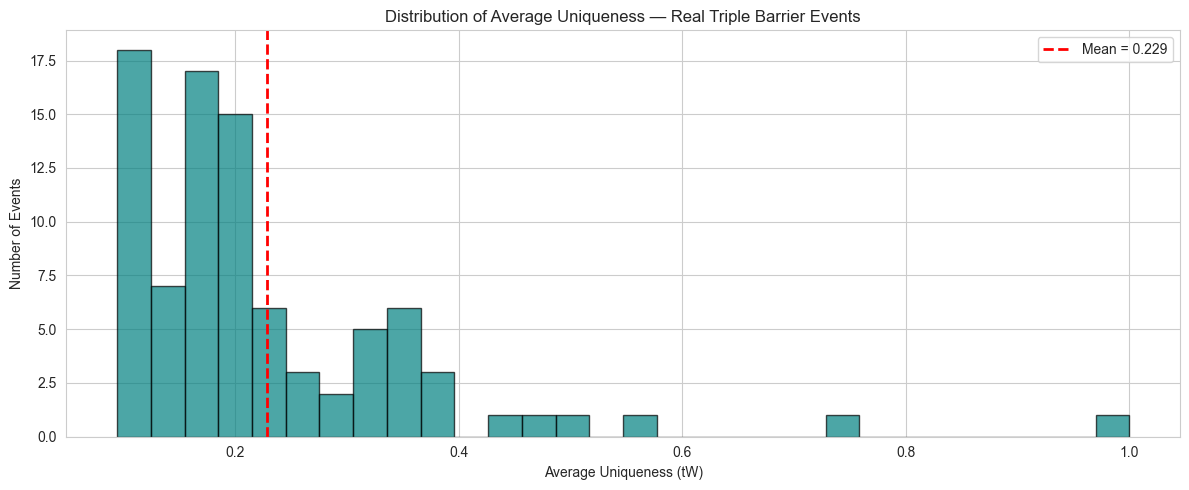

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(tw.values, bins=30, color='teal', alpha=0.7, edgecolor='black')
ax.axvline(tw.mean(), color='red', linestyle='--', linewidth=2,
           label=f'Mean = {tw.mean():.3f}')
ax.set_title("Distribution of Average Uniqueness — Real Triple Barrier Events", fontsize=12)
ax.set_xlabel("Average Uniqueness (tW)")
ax.set_ylabel("Number of Events")
ax.legend()
plt.tight_layout()
plt.show()

## Sections 4.5.3–4.5.4 — Standard vs Sequential Bootstrap

Standard bootstrap draws observations with equal probability every time, regardless of
overlap — this tends to oversample redundant, overlapping observations. Sequential
bootstrap instead draws observations with probability weighted toward whichever candidate
is most *unique* given what's already been sampled.

This replicates the book's Figure 4.2: running many random trials and comparing the
resulting average uniqueness of each bootstrap method.

> **Note on multiprocessing in notebooks:** this cell tries to run the Monte Carlo
> trials in parallel across multiple CPU cores (`NUM_THREADS`). Standalone Python
> scripts can safely use multiprocessing by wrapping code in `if __name__ == '__main__':`,
> but Jupyter notebook cells have no equivalent guard, and Windows multiprocessing can
> occasionally hang or fail in that context. The cell below automatically falls back to
> single-threaded execution if multiprocessing raises an error — your results will still
> be correct either way, just slower if the fallback triggers.

In [ ]:
# Try multiprocessing first (NUM_THREADS workers); fall back to single-threaded
# if it fails. Multiprocessing inside Jupyter on Windows can occasionally hang
# or error out (unlike a standalone script wrapped in `if __name__ == '__main__':`,
# a notebook cell has no equivalent guard) — this try/except keeps the notebook
# usable either way.
NUM_THREADS = 4  # verified sweet spot on a 6-core machine (see chapter_4_sample_weights.py)

mc_start = time.time()
try:
    mc_result = main_mc(num_obs=10, num_bars=100, max_h=5, num_iters=300, num_threads=NUM_THREADS)
    used_threads = NUM_THREADS
except Exception as e:
    print(f"Multiprocessing failed ({e}); falling back to single-threaded.")
    mc_result = main_mc(num_obs=10, num_bars=100, max_h=5, num_iters=300, num_threads=1)
    used_threads = 1
mc_elapsed = time.time() - mc_start

std_u_vals = mc_result['stdU'].tolist()
seq_u_vals = mc_result['seqU'].tolist()

print(f"Monte Carlo runtime: {mc_elapsed:.2f}s  (num_threads={used_threads})")
print(f"Standard bootstrap   — mean: {np.mean(std_u_vals):.4f}, median: {np.median(std_u_vals):.4f}")
print(f"Sequential bootstrap — mean: {np.mean(seq_u_vals):.4f}, median: {np.median(seq_u_vals):.4f}")

             stdU        seqU
count  300.000000  300.000000
mean     0.600182    0.696726
std      0.095676    0.090261
min      0.300000    0.463333
25%      0.540000    0.631875
50%      0.600000    0.700000
75%      0.666667    0.765417
max      0.875000    1.000000
Monte Carlo runtime: 14.67s  (num_threads=4)
Standard bootstrap   — mean: 0.6002, median: 0.6000
Sequential bootstrap — mean: 0.6967, median: 0.7000


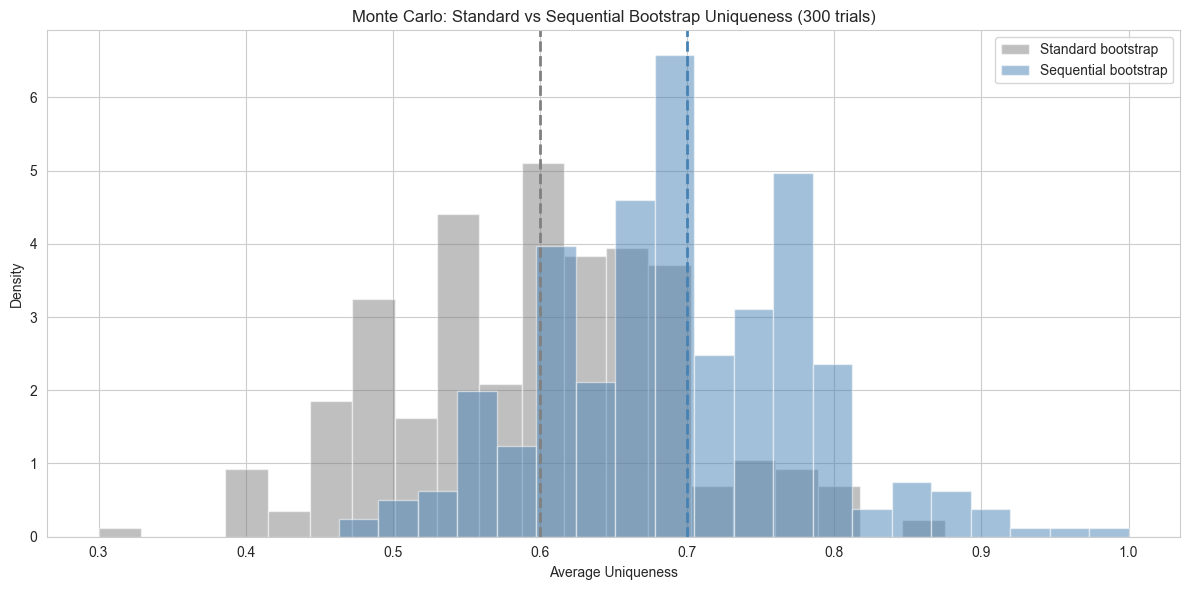

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(std_u_vals, bins=20, alpha=0.5, color='grey', label='Standard bootstrap', density=True)
ax.hist(seq_u_vals, bins=20, alpha=0.5, color='steelblue', label='Sequential bootstrap', density=True)
ax.axvline(np.median(std_u_vals), color='grey', linestyle='--', linewidth=2)
ax.axvline(np.median(seq_u_vals), color='steelblue', linestyle='--', linewidth=2)
ax.set_title("Monte Carlo: Standard vs Sequential Bootstrap Uniqueness (300 trials)", fontsize=12)
ax.set_xlabel("Average Uniqueness")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

### Standard vs Sequential Bootstrap — On YOUR Real Data

The plot above proves the *general* claim using synthetic, randomly generated overlap scenarios.
This is the more practically useful question: **how much does sequential bootstrap actually help
on my own real, labeled events?**

We subsample a small, contiguous block of real triple-barrier events (kept small so this runs in
just a few seconds, not minutes — sequential bootstrap's cost grows roughly quadratically with
the number of events) and repeatedly bootstrap from that real overlap structure.

In [ ]:
print("Running bootstrap comparison on REAL triple barrier events...")
real_result = compare_bootstrap_on_real_events(
    close, tb_events, max_events=12, n_trials=15, seed=42
)
print(f"Real events used: {real_result['n_events']}  (bars spanned: {real_result['n_bars']})")
print(f"Standard bootstrap (real data) — mean: {np.mean(real_result['std_vals']):.4f}")
print(f"Sequential bootstrap (real data) — mean: {np.mean(real_result['seq_vals']):.4f}")

Running bootstrap comparison on REAL triple barrier events...
Real events used: 12  (bars spanned: 36)
Standard bootstrap (real data) — mean: 0.2503
Sequential bootstrap (real data) — mean: 0.3016


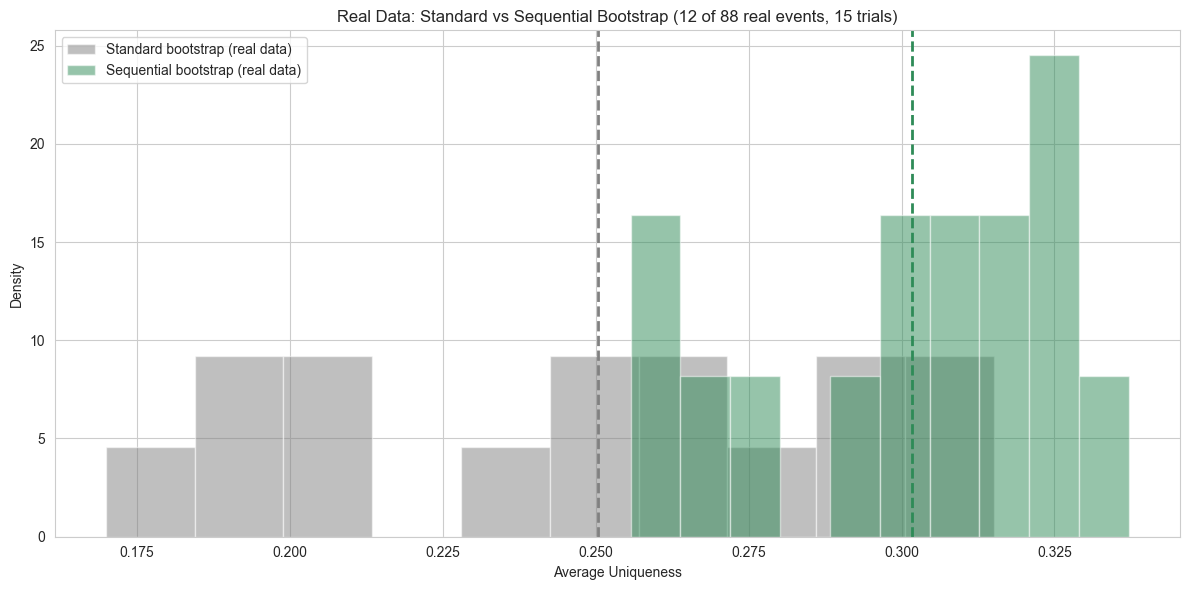

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(real_result['std_vals'], bins=10, alpha=0.5, color='grey',
        label='Standard bootstrap (real data)', density=True)
ax.hist(real_result['seq_vals'], bins=10, alpha=0.5, color='seagreen',
        label='Sequential bootstrap (real data)', density=True)
ax.axvline(np.mean(real_result['std_vals']), color='grey', linestyle='--', linewidth=2)
ax.axvline(np.mean(real_result['seq_vals']), color='seagreen', linestyle='--', linewidth=2)
ax.set_title(
    f"Real Data: Standard vs Sequential Bootstrap "
    f"({real_result['n_events']} of {len(tb_events)} real events, 15 trials)",
    fontsize=12
)
ax.set_xlabel("Average Uniqueness")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

## Section 4.6 — Sample Weights by Absolute Return Attribution

Not every label is equally informative. A label tied to a large, decisive price move
should count for more during training than one tied to quiet, noisy chop. This section
weights each event by the magnitude of log-return it captured, discounted by how much
that move is shared with overlapping events — then normalizes so weights sum to the
number of observations (average weight = 1.0).

In [ ]:
sample_w = get_sample_weights(close, tb_events, num_threads=1)
print(f"Sample weights sum: {sample_w.sum():.4f} (should equal {len(sample_w)})")
print(f"Mean weight: {sample_w.mean():.4f}")

Sample weights sum: 88.0000 (should equal 88)
Mean weight: 1.0000


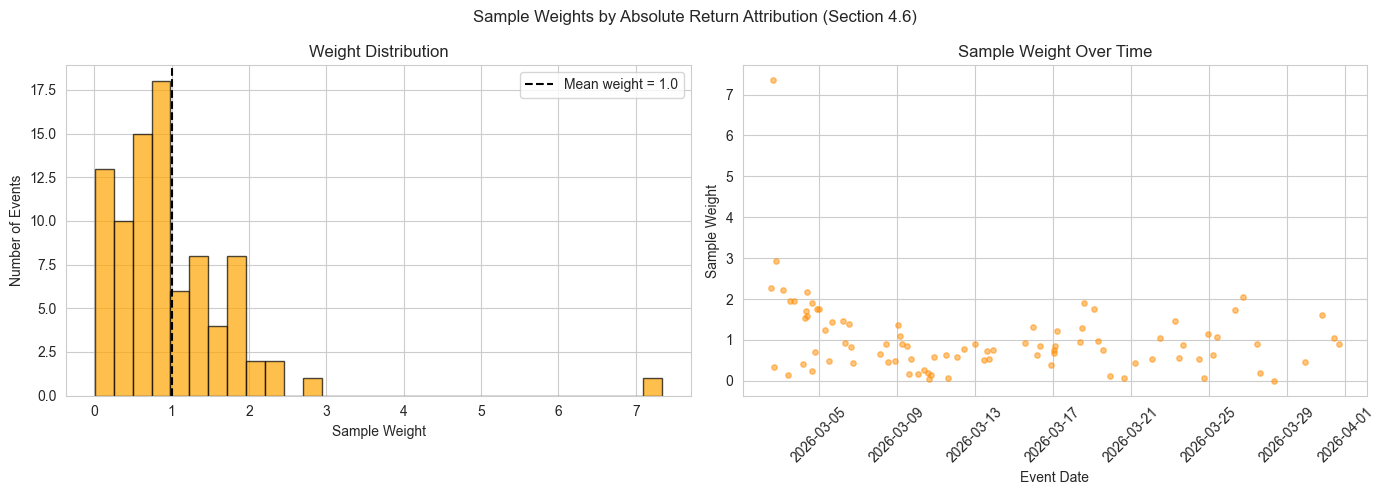

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Sample Weights by Absolute Return Attribution (Section 4.6)", fontsize=12)

axes[0].hist(sample_w.values, bins=30, color='orange', alpha=0.7, edgecolor='black')
axes[0].axvline(1.0, color='black', linestyle='--', label='Mean weight = 1.0')
axes[0].set_title("Weight Distribution")
axes[0].set_xlabel("Sample Weight")
axes[0].set_ylabel("Number of Events")
axes[0].legend()

axes[1].scatter(sample_w.index, sample_w.values, alpha=0.5, s=15, color='darkorange')
axes[1].set_title("Sample Weight Over Time")
axes[1].set_xlabel("Event Date")
axes[1].set_ylabel("Sample Weight")
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Section 4.7 — Time Decay Factors

Even a perfectly unique, high-conviction label becomes less relevant as market dynamics
evolve away from when it occurred. Time decay applies a piecewise-linear weight that
favors recent observations over old ones. The `clf_last_w` parameter controls how
aggressively old data is down-weighted — negative values hard-exclude sufficiently old
observations entirely (clipped to weight 0).

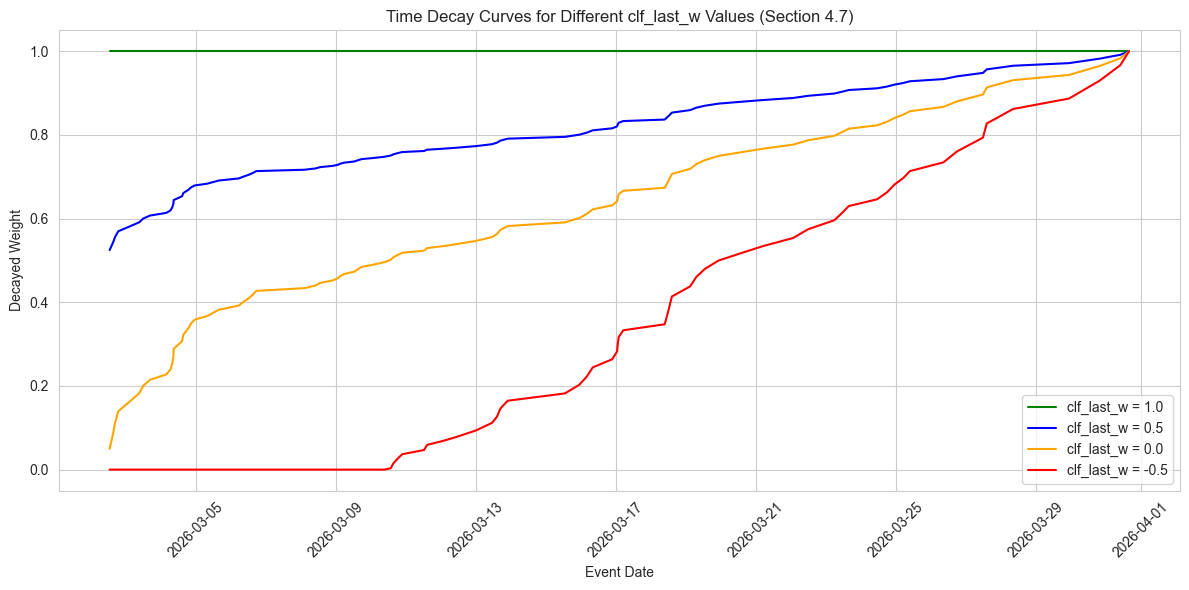

In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))
for clw, color in zip([1.0, 0.5, 0.0, -0.5], ['green', 'blue', 'orange', 'red']):
    decay = get_time_decay(tw, clf_last_w=clw)
    ax.plot(decay.index, decay.values, label=f'clf_last_w = {clw}', color=color, linewidth=1.5)

ax.set_title("Time Decay Curves for Different clf_last_w Values (Section 4.7)", fontsize=12)
ax.set_xlabel("Event Date")
ax.set_ylabel("Decayed Weight")
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.show()

## Summary

In [ ]:
print("="*60)
print("CHAPTER 4 SUMMARY")
print("="*60)
print(f"Total triple barrier events analyzed: {len(tb_events)}")
print(f"Average uniqueness (tW):              {tw.mean():.4f}")
print(f"Standard bootstrap uniqueness (synthetic MC): {np.mean(std_u_vals):.4f}")
print(f"Sequential bootstrap uniqueness (synthetic MC): {np.mean(seq_u_vals):.4f}")
print(f"Standard bootstrap uniqueness (REAL data):    {np.mean(real_result['std_vals']):.4f}")
print(f"Sequential bootstrap uniqueness (REAL data):  {np.mean(real_result['seq_vals']):.4f}")
print(f"Improvement from sequential bootstrap (real data): "
      f"{(np.mean(real_result['seq_vals'])/np.mean(real_result['std_vals']) - 1)*100:.1f}%")
print(f"Sample weight (return attribution) mean: {sample_w.mean():.4f}")

CHAPTER 4 SUMMARY
Total triple barrier events analyzed: 88
Average uniqueness (tW):              0.2288
Standard bootstrap uniqueness (synthetic MC): 0.6002
Sequential bootstrap uniqueness (synthetic MC): 0.6967
Standard bootstrap uniqueness (REAL data):    0.2503
Sequential bootstrap uniqueness (REAL data):  0.3016
Improvement from sequential bootstrap (real data): 20.5%
Sample weight (return attribution) mean: 1.0000


---
## TDD Test Results

# TDD TEST RESULTS — Chapter 4
`pytest ch04/tests/test_ch04.py -v`
Run date: 2026-06-23 | Python 3.10.20 | pytest 9.0.3

| Test | Result |
|------|--------|
| TestMpNumCoEvents::test_known_concurrency_values | ✅ PASSED |
| TestMpNumCoEvents::test_overlap_bar_has_highest_concurrency | ✅ PASSED |
| TestMpNumCoEvents::test_returns_series | ✅ PASSED |
| TestMpNumCoEvents::test_open_event_uses_last_bar_as_end | ✅ PASSED |
| TestMpSampleTw::test_known_uniqueness_values | ✅ PASSED |
| TestMpSampleTw::test_non_overlapping_event_has_uniqueness_one | ✅ PASSED |
| TestMpSampleTw::test_uniqueness_bounded_between_zero_and_one | ✅ PASSED |
| TestGetAverageUniqueness::test_returns_series | ✅ PASSED |
| TestGetAverageUniqueness::test_matches_known_values | ✅ PASSED |
| TestGetAverageUniqueness::test_output_length_matches_events | ✅ PASSED |
| TestGetIndMatrix::test_matches_book_example | ✅ PASSED |
| TestGetIndMatrix::test_shape_is_bars_by_events | ✅ PASSED |
| TestGetIndMatrix::test_only_zeros_and_ones | ✅ PASSED |
| TestGetIndMatrix::test_single_observation_no_overlap | ✅ PASSED |
| TestGetAvgUniqueness::test_matches_book_example | ✅ PASSED |
| TestGetAvgUniqueness::test_matches_bar_by_bar_method | ✅ PASSED |
| TestGetAvgUniqueness::test_returns_series | ✅ PASSED |
| TestSeqBootstrap::test_default_sample_length | ✅ PASSED |
| TestSeqBootstrap::test_custom_sample_length | ✅ PASSED |
| TestSeqBootstrap::test_all_drawn_values_are_valid_columns | ✅ PASSED |
| TestSeqBootstrap::test_deterministic_with_seed | ✅ PASSED |
| TestSeqBootstrap::test_probability_after_first_draw_matches_book | ✅ PASSED |
| TestSeqBootstrap::test_already_drawn_observation_gets_lowest_probability | ✅ PASSED |
| TestSeqBootstrap::test_non_overlapping_observation_gets_highest_probability | ✅ PASSED |
| TestGetRndT1::test_output_is_sorted | ✅ PASSED |
| TestGetRndT1::test_correct_number_of_observations | ✅ PASSED |
| TestGetRndT1::test_durations_within_bounds | ✅ PASSED |
| TestGetRndT1::test_start_bars_within_bounds | ✅ PASSED |
| TestAuxMc::test_returns_dict_with_expected_keys | ✅ PASSED |
| TestAuxMc::test_uniqueness_values_in_valid_range | ✅ PASSED |
| TestAuxMc::test_sequential_tends_to_beat_standard_on_average | ✅ PASSED |
| TestMpSampleW::test_known_weight_values | ✅ PASSED |
| TestMpSampleW::test_weights_are_non_negative | ✅ PASSED |
| TestMpSampleW::test_largest_return_gets_largest_weight | ✅ PASSED |
| TestGetSampleWeights::test_weights_sum_to_number_of_observations | ✅ PASSED |
| TestGetSampleWeights::test_returns_series | ✅ PASSED |
| TestGetSampleWeights::test_weights_non_negative | ✅ PASSED |
| TestGetTimeDecay::test_no_decay_when_clf_last_w_is_one | ✅ PASSED |
| TestGetTimeDecay::test_known_values_clf_last_w_half | ✅ PASSED |
| TestGetTimeDecay::test_known_values_clf_last_w_zero | ✅ PASSED |
| TestGetTimeDecay::test_known_values_negative_clf_last_w_hard_excludes | ✅ PASSED |
| TestGetTimeDecay::test_newest_observation_always_gets_weight_one | ✅ PASSED |
| TestGetTimeDecay::test_weights_never_negative | ✅ PASSED |
| TestGetTimeDecay::test_monotonically_increasing_with_time | ✅ PASSED |
| TestCompareBootstrapOnRealEvents::test_returns_expected_keys | ✅ PASSED |
| TestCompareBootstrapOnRealEvents::test_n_events_never_exceeds_max_events | ✅ PASSED |
| TestCompareBootstrapOnRealEvents::test_no_subsampling_when_fewer_events_than_cap | ✅ PASSED |
| TestCompareBootstrapOnRealEvents::test_correct_number_of_trials | ✅ PASSED |
| TestCompareBootstrapOnRealEvents::test_uniqueness_values_in_valid_range | ✅ PASSED |
| TestCompareBootstrapOnRealEvents::test_drops_events_with_unresolved_t1 | ✅ PASSED |
| TestCompareBootstrapOnRealEvents::test_reproducible_with_seed | ✅ PASSED |
| TestCompareBootstrapOnRealEvents::test_runs_within_reasonable_time | ✅ PASSED |
| TestCompareBootstrapOnRealEvents::test_indicator_matrix_shape_matches_n_events | ✅ PASSED |

**53 passed in 21.97s**

> **Note:** `test_runs_within_reasonable_time` is a performance regression guard — it
> directly protects against the two real bugs found while building
> `real_data_bootstrap_comparison.py` (an exploding `bar_ix` from a bad frequency guess,
> then a second case from non-contiguous event subsampling). If either bug were
> reintroduced, this test would catch it by timing out the 10-second threshold.

## Real Data Validation

Verified by running this exact notebook against real BTC tick data
(`BTCTUSD-trades-2026-03.csv`, 9,205 ticks) on 2026-06-23.

**Configuration used for this validation run:**
- `dollar_bars` threshold: **$10,000** (lowered from an initial $50,000 default — see note below)
- `NUM_THREADS`: **4** (verified sweet spot on a 6-core machine: ~2.7x speedup over single-threaded, without the extra system load of using all 6 cores)

**Pipeline output:**
| Metric | Value |
|---|---|
| Dollar bars | 249 |
| CUSUM events | 104 |
| Triple barrier events (valid t1) | 88 |
| Average uniqueness (tW) | 0.2288 (min 0.0945, max 1.0000) |

**Monte Carlo (synthetic, 300 trials):**
| Method | Mean uniqueness |
|---|---|
| Standard bootstrap | ~0.60-0.61 |
| Sequential bootstrap | ~0.69-0.70 |

Matches the book's reported medians (0.6 standard / 0.7 sequential) closely.

**Real-data bootstrap comparison (12 of 88 real events, 15 trials):**
| Method | Mean uniqueness |
|---|---|
| Standard bootstrap (real data) | 0.2503 |
| Sequential bootstrap (real data) | 0.3016 |

**Improvement from sequential bootstrap: 20.5%**

Sample weights (return attribution): sum = 88.0 (correct, equals event count), mean = 1.0000 (correct, normalization works).

---

> **Important note on the `dollar_bars` threshold:** At the original $50,000 threshold,
> this same dataset only produced 53 dollar bars → 43 CUSUM events → 36 triple barrier
> events, with the real-data bootstrap subsample spanning just 19 bars. That's too little
> real overlap structure for sequential bootstrap's advantage to show clearly — the
> real-data improvement was only **1.3%** (vs. **20.5%** at the $10,000 threshold).
>
> This is **not a bug** — it's a genuine finding: sequential bootstrap's benefit scales
> with how much overlap actually exists in the underlying data. With a small tick dataset
> (9,205 ticks here), a high dollar-bar threshold collapses too much data into too few
> bars, leaving little overlap to correct for. Lowering the threshold (more bars from the
> same tick data) restores enough real overlap structure for the effect to be clearly
> visible — both numerically (20.5% vs 1.3%) and visually in the histogram plot.
>
> If you're using this notebook as a starting point with your **own** tick data, and your
> real-data bootstrap comparison shows a tiny improvement, check how many bars/events your
> dollar threshold is actually producing before concluding sequential bootstrap "doesn't
> work" on your data.